# EDA transport - Paris et Ile-de-France

## Objectif
Construire une base d'analyse lisible pour de futurs indicateurs cartographiques sur les transports a Paris et en Ile-de-France.
Le notebook est volontairement ecrit avec du code simple, repetitif et local a chaque section pour rester facile a relire et a modifier.

## Jeux de donnees analyses
- Velib - stations et disponibilite temps reel
- Comptage multimodal - volumes par mode et par trajectoire
- Gares IDF - gares et dessertes par ligne
- Arrets IDF - referentiel des arrets

## Fil conducteur
1. Comprendre le sens metier de chaque colonne.
2. Tester la qualite de donnees et les duplications.
3. Identifier ce qui est reellement exploitable pour des indices spatiaux.
4. Conclure sur les jointures possibles et les limites de chaque source.


## 1. Parametres generaux

Cette section garde uniquement les imports et les options d'affichage.
Les traitements de chargement, profilage et visualisation sont ensuite places directement dans les sections ou ils servent.


In [1]:
import json
import time
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 120)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

print('Configuration chargee')
print(f'Pandas: {pd.__version__} | Numpy: {np.__version__}')
print(f"Date d'analyse: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Configuration chargee
Pandas: 2.2.3 | Numpy: 2.2.3
Date d'analyse: 2026-06-11 13:51:31


In [2]:
def fetch_api_data(base_url, dataset_id, rows=2000, batch_size=100, max_retries=5, pause_seconds=2):
    records = []
    offset = 0
    headers = {
        'User-Agent': 'Mozilla/5.0',
        'Accept': 'application/json',
        'Connection': 'close',
    }

    while len(records) < rows:
        url = f"{base_url}/{dataset_id}/records"
        params = {
            'limit': min(batch_size, rows - len(records)),
            'offset': offset,
        }

        payload = None
        last_error = None

        for attempt in range(max_retries):
            try:
                response = requests.get(url, params=params, headers=headers, timeout=(10, 60))
                response.raise_for_status()
                payload = response.json()
                break
            except requests.exceptions.RequestException as error:
                last_error = error
                wait_time = pause_seconds * (attempt + 1)
                print(f"Tentative {attempt + 1}/{max_retries} echouee pour {dataset_id} a l'offset {offset}: {error}")
                if attempt < max_retries - 1:
                    print(f'Nouvel essai dans {wait_time} seconde(s)...')
                    time.sleep(wait_time)

        if payload is None:
            raise RuntimeError(
                f"Echec du chargement API pour {dataset_id} apres {max_retries} tentatives. "
                f"Derniere erreur: {last_error}"
            )

        batch = payload.get('results', [])
        if not batch:
            break

        records.extend(batch)
        offset += len(batch)

        total_count = payload.get('total_count')
        if total_count is not None and offset >= total_count:
            break

        time.sleep(0.3)

    return pd.DataFrame(records)

print('Fonction API prete')


Fonction API prete


## 2. Analyse du dataset Velib

Points de lecture metier a verifier: taille de station via la capacite, presence de borne de paiement, communes couvertes, position par arrondissement, et separation entre variables statiques et variables dynamiques temps reel.
L'objectif est de savoir si cette source peut alimenter des indices de densite de stations, de capacite cumulee et d'accessibilite Velib a l'echelle d'un arrondissement.


In [7]:
velib_cfg = {
    'base_url': 'https://opendata.paris.fr/api/explore/v2.1/catalog/datasets',
    'dataset_id': 'velib-disponibilite-en-temps-reel',
    'rows': 2000,
    'batch_size': 100,
}

df_velib = fetch_api_data(
    velib_cfg['base_url'],
    velib_cfg['dataset_id'],
    rows=velib_cfg['rows'],
    batch_size=velib_cfg['batch_size'],
)

print('=== Velib ===')
print(f'Lignes: {len(df_velib)} | Colonnes: {df_velib.shape[1]}')
print('Colonnes:')
print(df_velib.columns.tolist())
display(df_velib.head(5))

df_velib_hashable = df_velib.copy()
for column in df_velib_hashable.columns:
    df_velib_hashable[column] = df_velib_hashable[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True) if isinstance(value, (list, dict)) else value
    )
print(f'Doublons exacts: {int(df_velib_hashable.duplicated().sum())}')

velib_profile_rows = []
for column in df_velib.columns:
    series = df_velib[column]
    safe_series = df_velib_hashable[column]
    velib_profile_rows.append({
        'column': column,
        'dtype': str(series.dtype),
        'null_count': int(series.isna().sum()),
        'null_pct': round(float(series.isna().mean() * 100), 2),
        'n_unique': int(safe_series.nunique(dropna=True)),
        'sample_values': ' | '.join(safe_series.dropna().astype(str).unique()[:5]) if safe_series.notna().any() else '-',
    })

velib_profile = pd.DataFrame(velib_profile_rows).sort_values(['null_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True)
display(velib_profile)

velib_numeric_cols = df_velib.select_dtypes(include='number').columns.tolist()
if velib_numeric_cols:
    display(df_velib[velib_numeric_cols].describe().T)


=== Velib ===
Lignes: 1517 | Colonnes: 15
Colonnes:
['stationcode', 'name', 'is_installed', 'capacity', 'numdocksavailable', 'numbikesavailable', 'mechanical', 'ebike', 'is_renting', 'is_returning', 'duedate', 'coordonnees_geo', 'nom_arrondissement_communes', 'code_insee_commune', 'station_opening_hours']


,stationcode,name,is_installed,capacity,numdocksavailable,numbikesavailable,mechanical,ebike,is_renting,is_returning,duedate,coordonnees_geo,nom_arrondissement_communes,code_insee_commune,station_opening_hours
0,32304,Charcot - Benfleet,OUI,28,15,13,1,12,OUI,OUI,2026-06-10T18:54:58+00:00,"{'lon': 2.440523876268, 'lat': 48.878370277021}",Romainville,93063,None
1,14014,Jourdan - Stade Charléty,OUI,60,45,13,1,12,OUI,OUI,2026-06-10T18:54:44+00:00,"{'lon': 2.3433353751898, 'lat': 48.819428333369}",Paris,75056,None
2,32017,Basilique,OUI,22,13,7,2,5,OUI,OUI,2026-06-10T18:55:55+00:00,"{'lon': 2.3588666820200914, 'lat': 48.93626891059109}",Saint-Denis,93066,None
3,7002,Vaneau - Sèvres,OUI,35,16,18,14,4,OUI,OUI,2026-06-10T18:56:03+00:00,"{'lon': 2.3204218259346, 'lat': 48.848563233059}",Paris,75056,None
4,33006,André Karman - République,OUI,31,24,5,3,2,OUI,OUI,2026-06-10T18:51:35+00:00,"{'lon': 2.3851355910301213, 'lat': 48.91039875761846}",Aubervilliers,93001,None


Doublons exacts: 18


,column,dtype,null_count,null_pct,n_unique,sample_values
0,station_opening_hours,object,1517,100.0,0,-
1,stationcode,object,0,0.0,1441,32304 | 14014 | 32017 | 7002 | 33006
2,coordonnees_geo,object,0,0.0,1441,"{""lat"": 48.878370277021, ""lon"": 2.440523876268} | {""lat"": 48.819428333369, ""lon"": 2.3433353751898} | {""lat"": 48.9362..."
3,name,object,0,0.0,1438,Charcot - Benfleet | Jourdan - Stade Charléty | Basilique | Vaneau - Sèvres | André Karman - République
4,duedate,object,0,0.0,435,2026-06-10T18:54:58+00:00 | 2026-06-10T18:54:44+00:00 | 2026-06-10T18:55:55+00:00 | 2026-06-10T18:56:03+00:00 | 2026...
5,nom_arrondissement_communes,object,0,0.0,69,Romainville | Paris | Saint-Denis | Aubervilliers | Ivry-sur-Seine
6,code_insee_commune,object,0,0.0,69,93063 | 75056 | 93066 | 93001 | 94041
7,capacity,int64,0,0.0,68,28 | 60 | 22 | 35 | 31
8,numdocksavailable,int64,0,0.0,62,15 | 45 | 13 | 16 | 24
9,numbikesavailable,int64,0,0.0,57,13 | 7 | 18 | 5 | 9


,count,mean,std,min,25%,50%,75%,max
capacity,1517.0,32.458141,19.294014,0.0,23.0,30.0,38.0,610.0
numdocksavailable,1517.0,19.499011,19.358669,0.0,10.0,17.0,27.0,600.0
numbikesavailable,1517.0,11.934740,10.064978,0.0,5.0,9.0,17.0,59.0
mechanical,1517.0,7.147660,8.966992,0.0,1.0,4.0,10.0,55.0
ebike,1517.0,4.787080,4.046255,0.0,2.0,4.0,7.0,31.0


### Dictionnaire de donnees VELIB

- `stationcode` : identifiant technique de la station
- `name` : nom complet de la station
- `nom_arrondissement_communes` : commune ou arrondissement rattache a la station
- `capacity` : capacite totale de station, utile comme proxy de taille
- `numbikesavailable` : nombre total de velos disponibles
- `numdocksavailable` : nombre total de bornettes libres
- `mechanical` : nombre de velos mecaniques disponibles
- `ebike` : nombre de velos electriques disponibles
- `is_renting` : station ouverte a la prise de velo
- `is_returning` : station ouverte au retour de velo
- `coordonnees_geo` ou champ equivalent : position de la station
- `creditcard` ou champ equivalent : presence d'un dispositif de paiement, si disponible dans la source


Stations par commune au total : 1517


,nom_arrondissement_communes,count
0,Paris,994
1,Boulogne-Billancourt,30
2,Montreuil,24
3,Pantin,20
4,Issy-les-Moulineaux,20
5,Saint-Denis,18
6,Vitry-sur-Seine,17
7,Ivry-sur-Seine,17
8,Créteil,17
9,Fontenay-sous-Bois,14


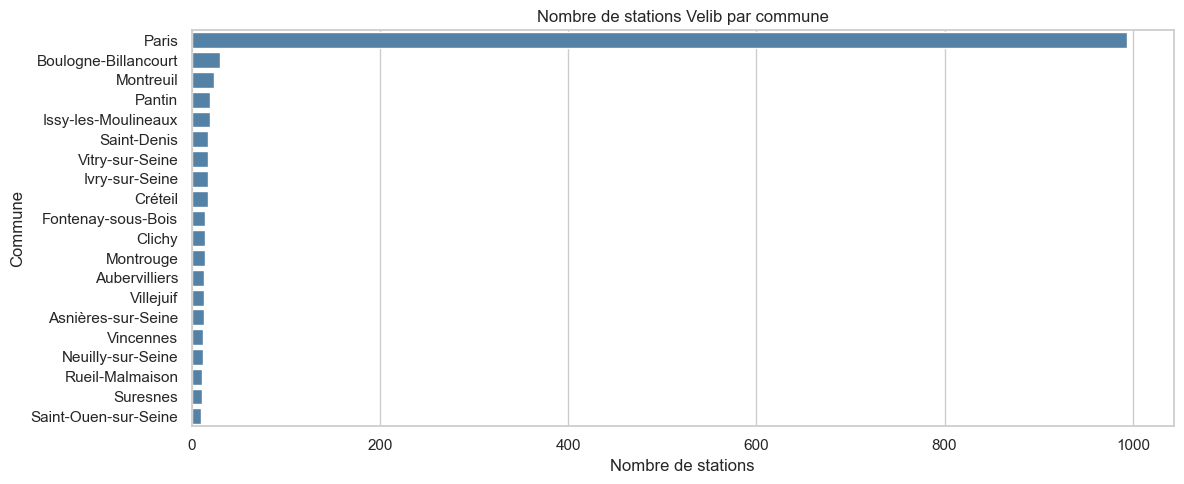

Filtrage Paris applique: 994 lignes conservees


In [40]:
if 'nom_arrondissement_communes' in df_velib.columns:
    commune_counts = df_velib['nom_arrondissement_communes'].astype(str).value_counts(dropna=False).reset_index()
    commune_counts.columns = ['nom_arrondissement_communes', 'count']
    print('Stations par commune au total :', int(commune_counts['count'].sum()))
    display(commune_counts.head(15))

    sns.barplot(data=commune_counts.head(20), x='count', y='nom_arrondissement_communes', color='steelblue')
    plt.title('Nombre de stations Velib par commune')
    plt.xlabel('Nombre de stations')
    plt.ylabel('Commune')
    plt.tight_layout()
    plt.show()

    paris_mask = df_velib['nom_arrondissement_communes'].astype(str).str.contains('Paris', case=False, na=False)
    if paris_mask.any():
        df_velib = df_velib.loc[paris_mask].copy()
        print(f'Filtrage Paris applique: {len(df_velib)} lignes conservees')
    else:
        print('Aucun filtrage Paris explicite n a pu etre applique')

### FIlTRAGE DE LA COMMUNE DE PARIS

In [ ]:
velib_paris = df_velib.copy()

velib_paris = velib_paris[velib_paris['nom_arrondissement_communes'] == 'Paris']
print(f'Stations Velib a Paris: {len(velib_paris)}')
display(velib_paris.head(5))

Stations Velib a Paris: 994


,stationcode,name,is_installed,capacity,numdocksavailable,numbikesavailable,mechanical,ebike,is_renting,is_returning,duedate,coordonnees_geo,nom_arrondissement_communes,code_insee_commune,station_opening_hours
1,14014,Jourdan - Stade Charléty,OUI,60,45,13,1,12,OUI,OUI,2026-06-10T18:54:44+00:00,"{'lon': 2.3433353751898, 'lat': 48.819428333369}",Paris,75056,None
3,7002,Vaneau - Sèvres,OUI,35,16,18,14,4,OUI,OUI,2026-06-10T18:56:03+00:00,"{'lon': 2.3204218259346, 'lat': 48.848563233059}",Paris,75056,None
8,7003,Square Boucicaut,OUI,60,27,29,28,1,OUI,OUI,2026-06-10T18:55:16+00:00,"{'lon': 2.325061820447445, 'lat': 48.851296433665276}",Paris,75056,None
9,17041,Guersant - Gouvion-Saint-Cyr,OUI,36,6,28,23,5,OUI,OUI,2026-06-10T18:55:56+00:00,"{'lon': 2.287667370814871, 'lat': 48.88287775178599}",Paris,75056,None
10,11025,Froment - Bréguet,OUI,43,6,37,31,6,OUI,OUI,2026-06-10T18:56:27+00:00,"{'lon': 2.37289470306807, 'lat': 48.8570414504784}",Paris,75056,None


In [ ]:
#velib_paris = df_velib.copy()

if 'nom_arrondissement_communes' in velib_paris.columns:
    commune_counts = velib_paris['nom_arrondissement_communes'].astype(str).value_counts(dropna=False).reset_index()
    commune_counts.columns = ['nom_arrondissement_communes', 'count']
    print('Stations par commune au total :', int(commune_counts['count'].sum()))
    display(commune_counts.head(15))


    paris_mask = velib_paris['nom_arrondissement_communes'].astype(str).str.contains('Paris', case=False, na=False)
    if paris_mask.any():
        velib_paris = velib_paris.loc[paris_mask].copy()
        print(f'Filtrage Paris applique: {len(velib_paris)} lignes conservees')
    else:
        print('Aucun filtrage Paris explicite n a pu etre applique')

if 'capacity' in velib_paris.columns and 'nom_arrondissement_communes' in velib_paris.columns:
    capacity_by_arr = velib_paris.groupby('nom_arrondissement_communes', dropna=False)['capacity'].agg(['count', 'sum', 'mean']).reset_index()
    capacity_by_arr.columns = ['nom_arrondissement_communes', 'nb_stations', 'capacity_cumulee', 'capacity_moyenne']
    capacity_by_arr = capacity_by_arr.sort_values('capacity_cumulee', ascending=False)
    display(capacity_by_arr.head(15))


Stations par commune au total : 994


,nom_arrondissement_communes,count
0,Paris,994


Filtrage Paris applique: 994 lignes conservees


,nom_arrondissement_communes,nb_stations,capacity_cumulee,capacity_moyenne
0,Paris,994,34095,34.300805


Colonnes statiques probables:
['stationcode', 'name', 'is_installed', 'capacity', 'coordonnees_geo', 'nom_arrondissement_communes', 'code_insee_commune', 'station_opening_hours']

Colonnes dynamiques probables:
['numbikesavailable', 'numdocksavailable', 'mechanical', 'ebike', 'is_renting', 'is_returning', 'duedate']

Distribution de la capacite des stations
count    994.000000
mean      34.300805
std       22.619829
min        0.000000
25%       23.000000
50%       32.000000
75%       42.000000
max      610.000000
Name: capacity, dtype: float64


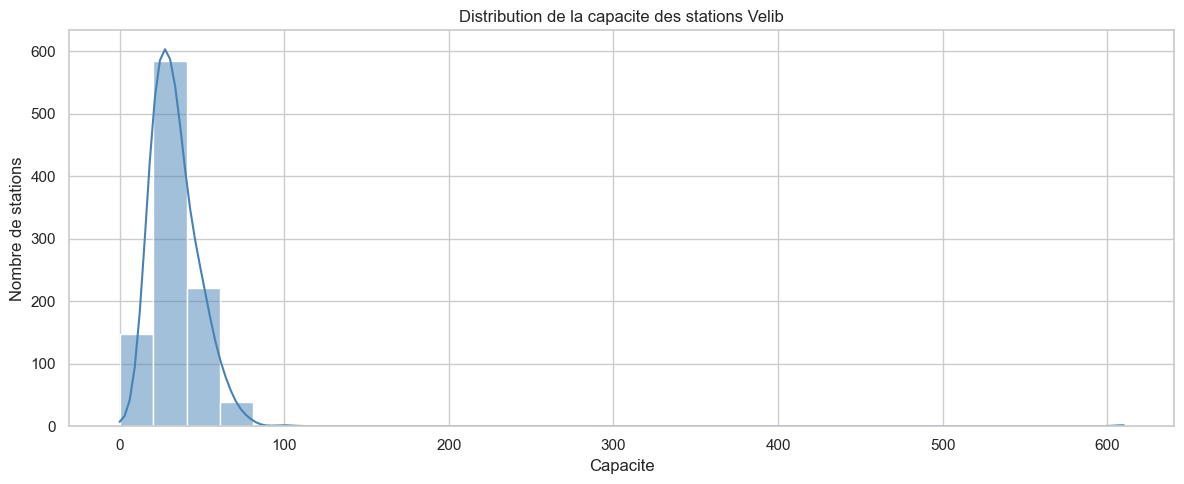

In [48]:
print('Colonnes statiques probables:')
print([column for column in velib_paris.columns if column not in ['numbikesavailable', 'numdocksavailable', 'mechanical', 'ebike', 'is_renting', 'is_returning', 'duedate']])

print('\nColonnes dynamiques probables:')
print([column for column in ['numbikesavailable', 'numdocksavailable', 'mechanical', 'ebike', 'is_renting', 'is_returning', 'duedate'] if column in velib_paris.columns])

print('\nDistribution de la capacite des stations')
print(velib_paris['capacity'].describe())

sns.histplot(velib_paris['capacity'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution de la capacite des stations Velib')
plt.xlabel('Capacite')
plt.ylabel('Nombre de stations')
plt.tight_layout()
plt.show()

### TAKE OUT THE OUTLIER OF 610

In [49]:
#take out the stations with capacity above 500 as they are outliers
velib_paris = velib_paris[velib_paris['capacity'] <= 500]

,capacity,count
0,0,2
1,11,3
2,12,5
3,13,4
4,14,3
5,15,13
6,16,19
7,17,22
8,18,18
9,19,21


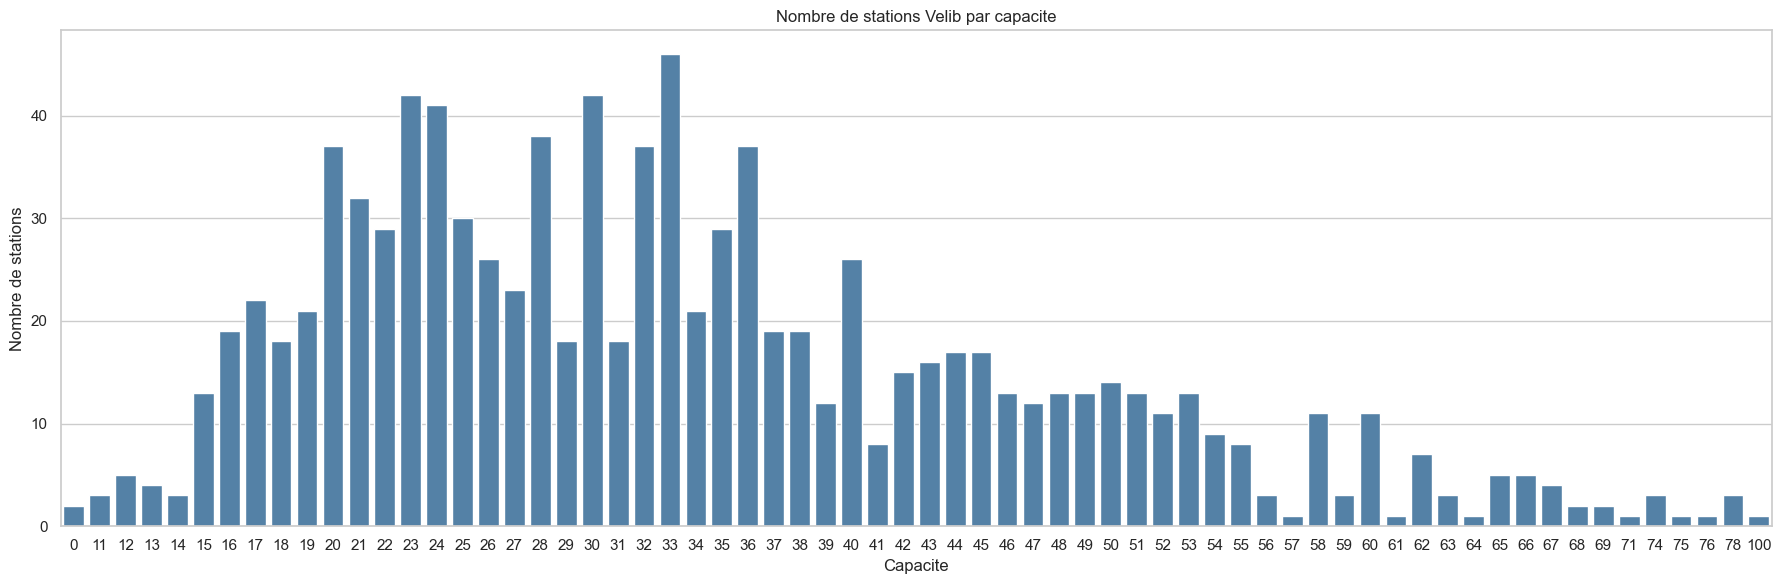

In [50]:
capacity_counts = velib_paris['capacity'].astype(str).value_counts(dropna=False).reset_index()
capacity_counts.columns = ['capacity', 'count']
capacity_counts = capacity_counts.sort_values('capacity', key=lambda x: pd.to_numeric(x, errors='coerce')).reset_index(drop=True)
display(capacity_counts.head(15))

plt.figure(figsize=(18, 6))
sns.barplot(data=capacity_counts, x='capacity', y='count', color='steelblue')
plt.title('Nombre de stations Velib par capacite')
plt.xlabel('Capacite')
plt.ylabel('Nombre de stations')
plt.tight_layout()
plt.show()


Statistiques descriptives sur les variables dynamiques


,numbikesavailable,numdocksavailable,mechanical,ebike
count,994.000000,994.00000,994.000000,994.000000
mean,12.557344,20.65493,7.908451,4.648893
std,10.997447,22.62801,9.919346,4.011120
min,0.000000,0.00000,0.000000,0.000000
25%,4.000000,10.00000,1.000000,2.000000
50%,9.000000,18.00000,4.000000,4.000000
75%,18.000000,29.00000,11.000000,6.000000
max,59.000000,600.00000,55.000000,27.000000


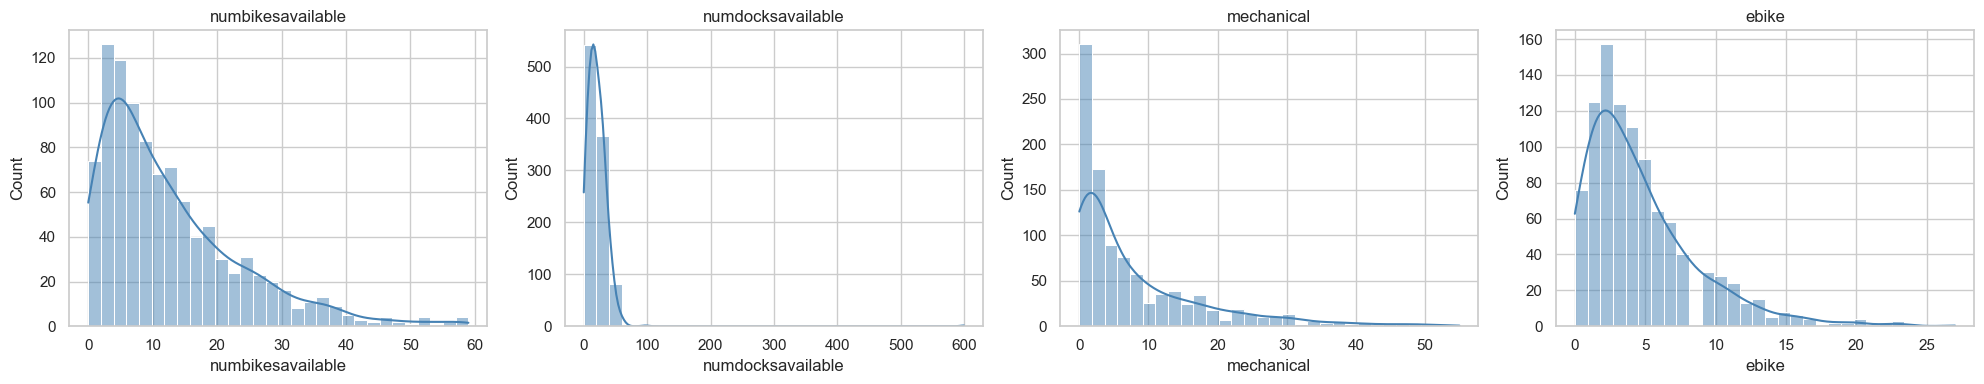

,is_renting,count
0,OUI,980
1,NON,14


,is_returning,count
0,OUI,980
1,NON,14


Conclusion Velib:
- La capacite est exploitable comme taille de station.
- Les colonnes de stock en temps reel doivent etre traitees comme des mesures instantanees.
- Le filtrage Paris est indispensable avant de calculer des indicateurs par arrondissement.
- Les indicateurs les plus naturels sont la densite de stations, la capacite cumulee et la part de stations avec paiement si la colonne existe.


In [43]:
dynamic_cols = [column for column in ['numbikesavailable', 'numdocksavailable', 'mechanical', 'ebike'] if column in velib_paris.columns]
if dynamic_cols:
    print('Statistiques descriptives sur les variables dynamiques')
    display(velib_paris[dynamic_cols].describe())

    fig, axes = plt.subplots(1, len(dynamic_cols), figsize=(5 * len(dynamic_cols), 4))
    if len(dynamic_cols) == 1:
        axes = [axes]
    for ax, column in zip(axes, dynamic_cols):
        sns.histplot(velib_paris[column].dropna(), bins=30, kde=True, color='steelblue', ax=ax)
        ax.set_title(column)
        ax.set_xlabel(column)
    plt.tight_layout()
    plt.show()

if 'is_renting' in velib_paris.columns:
    renting_counts = velib_paris['is_renting'].astype(str).value_counts(dropna=False).reset_index()
    renting_counts.columns = ['is_renting', 'count']
    display(renting_counts)

if 'is_returning' in velib_paris.columns:
    returning_counts = velib_paris['is_returning'].astype(str).value_counts(dropna=False).reset_index()
    returning_counts.columns = ['is_returning', 'count']
    display(returning_counts)

print('Conclusion Velib:')
print('- La capacite est exploitable comme taille de station.')
print('- Les colonnes de stock en temps reel doivent etre traitees comme des mesures instantanees.')
print('- Le filtrage Paris est indispensable avant de calculer des indicateurs par arrondissement.')
print('- Les indicateurs les plus naturels sont la densite de stations, la capacite cumulee et la part de stations avec paiement si la colonne existe.')


## 3. Analyse du dataset Comptage multimodal

Cette source doit etre lue avec prudence: il faut verifier si elle porte seulement un point de comptage, une trajectoire locale ou une geometrie plus riche de voie.
L'analyse vise surtout a identifier les categories de vehicules, les differences par type de file, par sens et par trajectoire, puis a evaluer ce qui peut vraiment etre agrege spatialement.


In [11]:
comptage_cfg = {
    'base_url': 'https://parisdata.opendatasoft.com/api/explore/v2.1/catalog/datasets',
    'dataset_id': 'comptage-multimodal-comptages',
    'rows': 2000,
    'batch_size': 100,
}

df_comptage = fetch_api_data(
    comptage_cfg['base_url'],
    comptage_cfg['dataset_id'],
    rows=comptage_cfg['rows'],
    batch_size=comptage_cfg['batch_size'],
)

print('=== Comptage multimodal ===')
print(f'Lignes: {len(df_comptage)} | Colonnes: {df_comptage.shape[1]}')
print('Colonnes:')
print(df_comptage.columns.tolist())
display(df_comptage.head(5))

df_comptage_hashable = df_comptage.copy()
for column in df_comptage_hashable.columns:
    df_comptage_hashable[column] = df_comptage_hashable[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True) if isinstance(value, (list, dict)) else value
    )
print(f'Doublons exacts: {int(df_comptage_hashable.duplicated().sum())}')

comptage_profile_rows = []
for column in df_comptage.columns:
    series = df_comptage[column]
    safe_series = df_comptage_hashable[column]
    comptage_profile_rows.append({
        'column': column,
        'dtype': str(series.dtype),
        'null_count': int(series.isna().sum()),
        'null_pct': round(float(series.isna().mean() * 100), 2),
        'n_unique': int(safe_series.nunique(dropna=True)),
        'sample_values': ' | '.join(safe_series.dropna().astype(str).unique()[:5]) if safe_series.notna().any() else '-',
    })

comptage_profile = pd.DataFrame(comptage_profile_rows).sort_values(['null_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True)
display(comptage_profile)

comptage_numeric_cols = df_comptage.select_dtypes(include='number').columns.tolist()
if comptage_numeric_cols:
    display(df_comptage[comptage_numeric_cols].describe().T)


=== Comptage multimodal ===
Lignes: 2000 | Colonnes: 10
Colonnes:
['id_trajectoire', 'id_site', 'label', 't', 'mode', 'nb_usagers', 'voie', 'sens', 'trajectoire', 'coordonnees_geo']


,id_trajectoire,id_site,label,t,mode,nb_usagers,voie,sens,trajectoire,coordonnees_geo
0,10004_1 -> 1,10004,CF0256_88 rue de Rivoli,2025-12-03T04:00:00+00:00,Vélos,15,Piste cyclable,O-E,1 -> 1,"{'lon': 2.349109, 'lat': 48.858273}"
1,10004_1 -> 1,10004,CF0256_88 rue de Rivoli,2025-12-03T07:00:00+00:00,Vélos,289,Piste cyclable,O-E,1 -> 1,"{'lon': 2.349109, 'lat': 48.858273}"
2,10004_1 -> 1,10004,CF0256_88 rue de Rivoli,2025-12-03T09:00:00+00:00,"Véhicules légers < 3,5t",1,Piste cyclable,O-E,1 -> 1,"{'lon': 2.349109, 'lat': 48.858273}"
3,10004_2 -> 1,10004,CF0256_88 rue de Rivoli,2025-12-03T02:00:00+00:00,Trottinettes,4,Piste cyclable,E-O,2 -> 1,"{'lon': 2.349109, 'lat': 48.858273}"
4,10004_2 -> 1,10004,CF0256_88 rue de Rivoli,2025-12-03T09:00:00+00:00,Vélos,2,Piste cyclable,E-O,2 -> 1,"{'lon': 2.349109, 'lat': 48.858273}"


Doublons exacts: 0


,column,dtype,null_count,null_pct,n_unique,sample_values
0,coordonnees_geo,object,234,11.7,39,"{""lat"": 48.858273, ""lon"": 2.349109} | {""lat"": 48.883513, ""lon"": 2.327263} | {""lat"": 48.875967, ""lon"": 2.364635} | {""..."
1,label,object,222,11.1,40,CF0256_88 rue de Rivoli | CF0181_101 rue d'Amsterdam | 134 quai de Jemmapes | CF0892_65 rue de Rivoli (Bourdonnais) ...
2,sens,object,222,11.1,7,O-E | E-O | S-N | N-S | SE-NO
3,voie,object,222,11.1,4,Piste cyclable | Coronapiste | Voie de circulation générale | Voie Bus
4,t,object,0,0.0,465,2025-12-03T04:00:00+00:00 | 2025-12-03T07:00:00+00:00 | 2025-12-03T09:00:00+00:00 | 2025-12-03T02:00:00+00:00 | 2025...
5,nb_usagers,int64,0,0.0,299,15 | 289 | 1 | 4 | 2
6,id_trajectoire,object,0,0.0,177,10004_1 -> 1 | 10004_2 -> 1 | 10004_4 -> 2 | 10004_5 -> 3 | 10004_3 -> 2
7,id_site,object,0,0.0,60,10004 | 10015 | 10020 | 10022 | 10023
8,trajectoire,object,0,0.0,20,1 -> 1 | 2 -> 1 | 4 -> 2 | 5 -> 3 | 3 -> 2
9,mode,object,0,0.0,8,"Vélos | Véhicules légers < 3,5t | Trottinettes | Autobus et autocars | 2 roues motorisées"


,count,mean,std,min,25%,50%,75%,max
nb_usagers,2000.0,53.1005,99.762536,1.0,3.0,12.0,47.0,857.0


### Dictionnaire de donnees COMPTAGE MULTIMODAL VOIES PUBLIQUES

- `id_site` : identifiant unique du point ou site de comptage
- `label` : libelle descriptif du site
- `coordonnees_geo` : position geographique du capteur ou du site
- `mode` : categorie ou mode compte
- `nb_usagers` : volume compte sur la periode
- `voie` : type de file ou de voie observee
- `sens` : sens de circulation
- `trajectoire` ou champ equivalent : orientation locale du flux
- `date` / `heure` / `t1` / `t2` selon la structure : temporalite de la mesure

Point de vigilance: ce jeu sert surtout a decrire un flux local mesure par capteur, pas toute la largeur de la rue ni tout l axe urbain.


In [51]:
if 'coordonnees_geo' in df_comptage.columns:
    print('La source contient une geometrie ponctuelle exploitable via coordonnees_geo')
    display(df_comptage['coordonnees_geo'].head(10))
else:
    print('Aucune colonne coordonnees_geo explicite dans cet echantillon')


La source contient une geometrie ponctuelle exploitable via coordonnees_geo


0    {'lon': 2.349109, 'lat': 48.858273}
1    {'lon': 2.349109, 'lat': 48.858273}
2    {'lon': 2.349109, 'lat': 48.858273}
3    {'lon': 2.349109, 'lat': 48.858273}
4    {'lon': 2.349109, 'lat': 48.858273}
5    {'lon': 2.349109, 'lat': 48.858273}
6    {'lon': 2.349109, 'lat': 48.858273}
7    {'lon': 2.349109, 'lat': 48.858273}
8    {'lon': 2.349109, 'lat': 48.858273}
9    {'lon': 2.349109, 'lat': 48.858273}
Name: coordonnees_geo, dtype: object

count    2000.000000
mean       53.100500
std        99.762536
min         1.000000
25%         3.000000
50%        12.000000
75%        47.000000
max       857.000000
Name: nb_usagers, dtype: float64


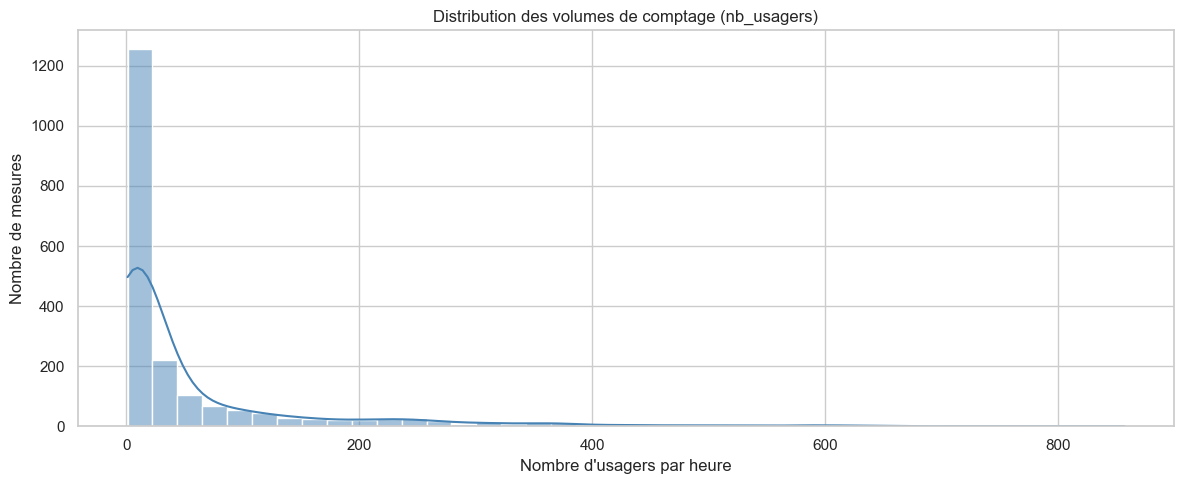

In [52]:

if 'nb_usagers' in df_comptage.columns:
    print(df_comptage['nb_usagers'].describe())

    sns.histplot(df_comptage['nb_usagers'].dropna(), bins=40, kde=True, color='steelblue')
    plt.title('Distribution des volumes de comptage (nb_usagers)')
    plt.xlabel("Nombre d'usagers par heure")
    plt.ylabel('Nombre de mesures')
    plt.tight_layout()
    plt.show()

,mode,count
0,Trottinettes + vélos,514
1,"Véhicules légers < 3,5t",324
2,2 roues motorisées,310
3,Trottinettes,240
4,"Véhicules lourds > 3,5t",189
5,Autobus et autocars,188
6,Vélos,150
7,van,85


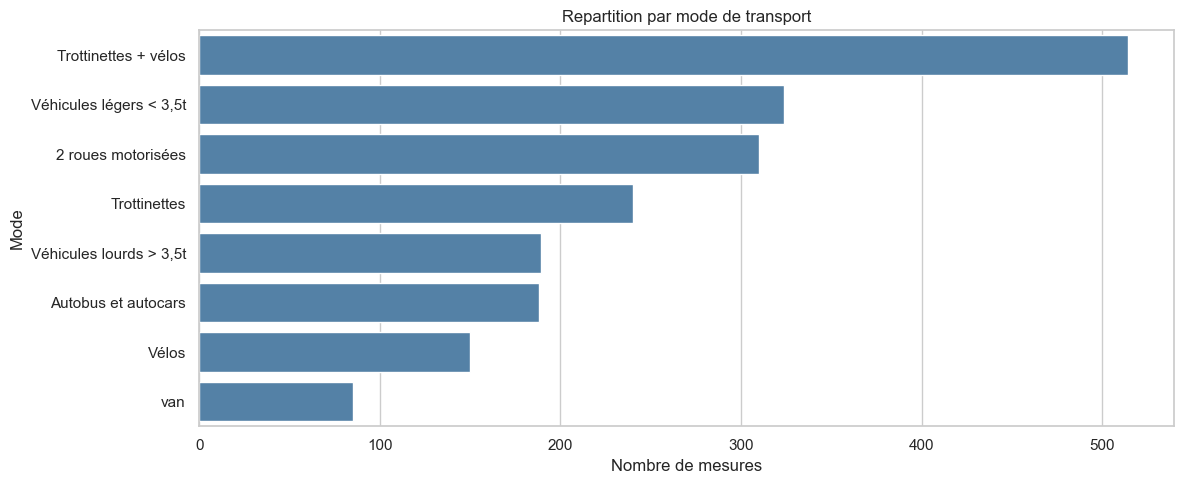

In [ ]:
if 'mode' in df_comptage.columns:
    mode_counts = df_comptage['mode'].astype(str).value_counts(dropna=False).reset_index()
    mode_counts.columns = ['mode', 'count']
    display(mode_counts)

    sns.barplot(data=mode_counts, x='count', y='mode', color='steelblue')
    plt.title('Repartition par mode de transport')
    plt.xlabel('Nombre de mesures')
    plt.ylabel('Mode')
    plt.tight_layout()
    plt.show()


,voie,count
0,Voie de circulation générale,919
1,Piste cyclable,402
2,Coronapiste,363
3,None,222
4,Voie Bus,94


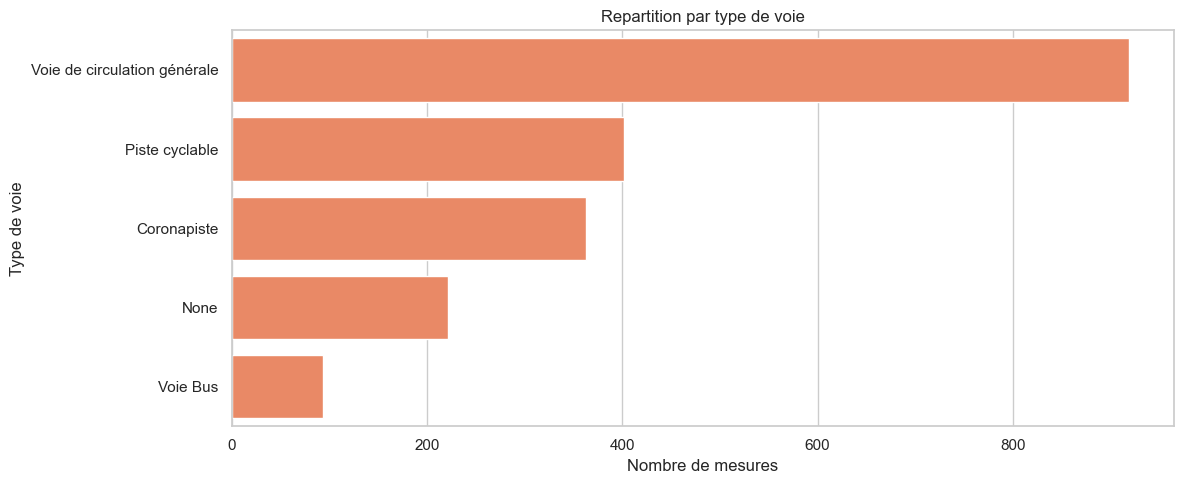

In [13]:
if 'voie' in df_comptage.columns:
    voie_counts = df_comptage['voie'].astype(str).value_counts(dropna=False).reset_index()
    voie_counts.columns = ['voie', 'count']
    display(voie_counts)

    sns.barplot(data=voie_counts, x='count', y='voie', color='coral')
    plt.title('Repartition par type de voie')
    plt.xlabel('Nombre de mesures')
    plt.ylabel('Type de voie')
    plt.tight_layout()
    plt.show()

,sens,count
0,E-O,804
1,S-N,327
2,O-E,317
3,N-S,261
4,None,222
5,NE-SO,30
6,SO-NE,27
7,SE-NO,12


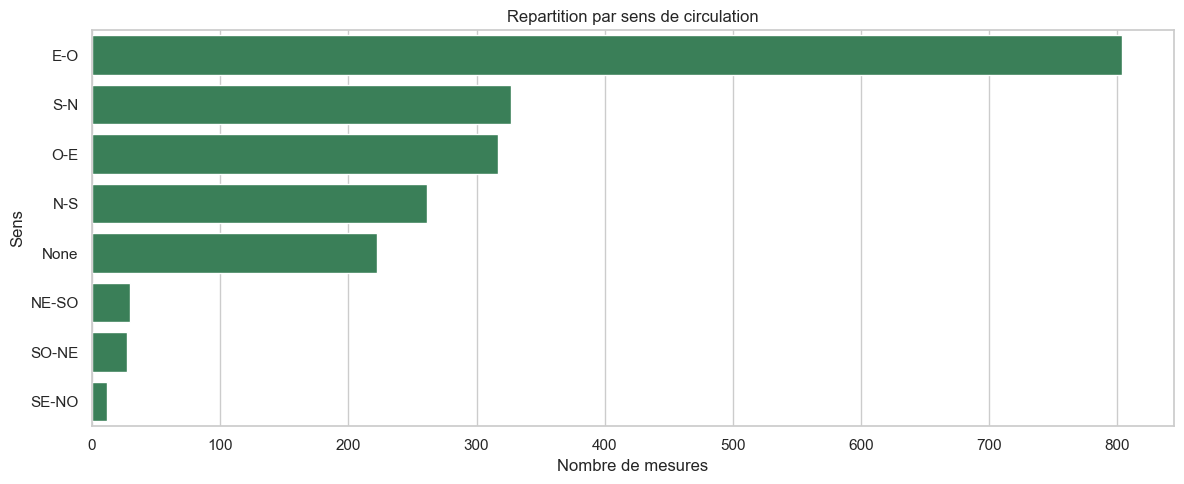

In [14]:
if 'sens' in df_comptage.columns:
    sens_counts = df_comptage['sens'].astype(str).value_counts(dropna=False).reset_index()
    sens_counts.columns = ['sens', 'count']
    display(sens_counts)

    sns.barplot(data=sens_counts, x='count', y='sens', color='seagreen')
    plt.title('Repartition par sens de circulation')
    plt.xlabel('Nombre de mesures')
    plt.ylabel('Sens')
    plt.tight_layout()
    plt.show()

In [26]:

if 'trajectoire' in df_comptage.columns:
    trajectoire_counts = df_comptage['trajectoire'].astype(str).value_counts(dropna=False).reset_index()
    trajectoire_counts.columns = ['trajectoire', 'count']
    display(trajectoire_counts.head(20))

,trajectoire,count
0,1 -> 1,638
1,2 -> 1,214
2,2 -> 2,164
3,5 -> 3,155
4,1 -> 2,140
5,3 -> 2,116
6,4 -> 1,108
7,5 -> 1,88
8,4 -> 2,73
9,4 -> 3,70


,mode,nb_usagers_moyen
0,"Véhicules légers < 3,5t",125.280864
1,Vélos,90.526667
2,Trottinettes + vélos,72.535019
3,van,22.447059
4,2 roues motorisées,17.816129
5,Autobus et autocars,13.090426
6,Trottinettes,12.466667
7,"Véhicules lourds > 3,5t",9.862434


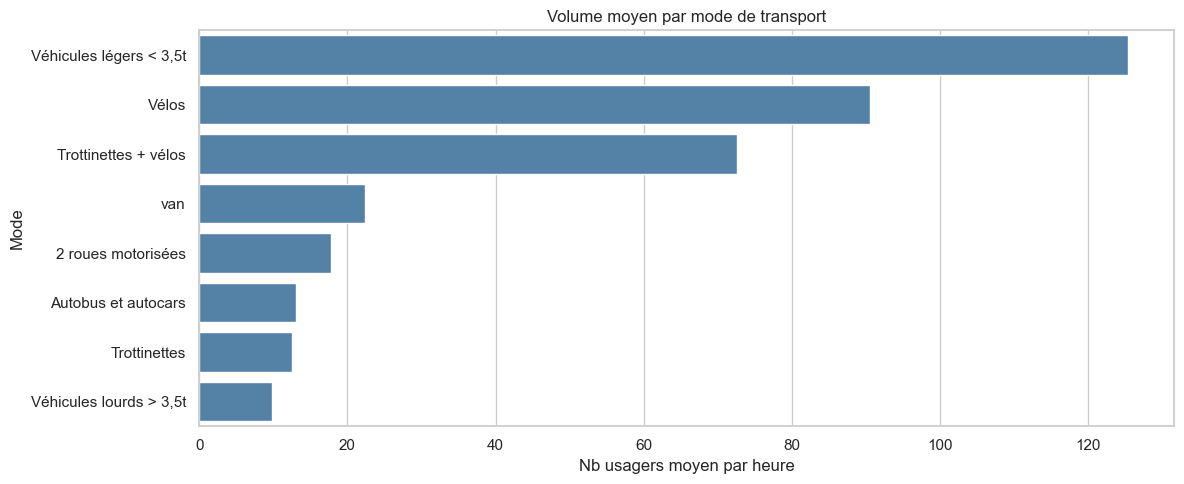

In [27]:
if 'mode' in df_comptage.columns and 'nb_usagers' in df_comptage.columns:
    avg_by_mode = df_comptage.groupby('mode', dropna=False)['nb_usagers'].mean().sort_values(ascending=False).reset_index()
    avg_by_mode.columns = ['mode', 'nb_usagers_moyen']
    display(avg_by_mode)

    sns.barplot(data=avg_by_mode, x='nb_usagers_moyen', y='mode', color='steelblue')
    plt.title('Volume moyen par mode de transport')
    plt.xlabel('Nb usagers moyen par heure')
    plt.ylabel('Mode')
    plt.tight_layout()
    plt.show()


In [16]:
if 'nom_arrondissement' in df_comptage.columns:
    arr_counts = df_comptage['nom_arrondissement'].astype(str).value_counts(dropna=False).reset_index()
    arr_counts.columns = ['nom_arrondissement', 'count']
    display(arr_counts.head(20))
elif 'arrondissement' in df_comptage.columns:
    arr_counts = df_comptage['arrondissement'].astype(str).value_counts(dropna=False).reset_index()
    arr_counts.columns = ['arrondissement', 'count']
    display(arr_counts.head(20))
else:
    print('Aucun arrondissement explicite dans cet echantillon: une jointure spatiale externe sera sans doute necessaire')

print('Conclusion Comptage multimodal:')
print('- La source semble decrire un point ou site de comptage localise, pas une rue complete.')
print('- Elle est utile pour reperer les axes les plus frequentes seulement si le site, la trajectoire et la voie sont bien interpretes.')
print('- Elle ne permet pas a elle seule de mesurer toute la largeur de route ni l ensemble d un boulevard.')
print('- Les indicateurs les plus realistes sont des flux locaux, des mix modaux et des comparaisons par sens ou par voie.')


Aucun arrondissement explicite dans cet echantillon: une jointure spatiale externe sera sans doute necessaire
Conclusion Comptage multimodal:
- La source semble decrire un point ou site de comptage localise, pas une rue complete.
- Elle est utile pour reperer les axes les plus frequentes seulement si le site, la trajectoire et la voie sont bien interpretes.
- Elle ne permet pas a elle seule de mesurer toute la largeur de route ni l ensemble d un boulevard.
- Les indicateurs les plus realistes sont des flux locaux, des mix modaux et des comparaisons par sens ou par voie.


## 4. Analyse du dataset Gares IDF

Ici, il faut distinguer la gare physique de la desserte par ligne. Un meme lieu peut apparaitre plusieurs fois s'il est desservi par plusieurs lignes, ce qui cree des doublons logiques mais utiles pour mesurer l'intensite de desserte.
L'enjeu est de compter les modes, les gares uniques et les relations gare-ligne qui peuvent alimenter un indice d'accessibilite ferrie ou de multimodalite.


In [3]:
gares_cfg = {
    'base_url': 'https://data.iledefrance-mobilites.fr/api/explore/v2.1/catalog/datasets',
    'dataset_id': 'emplacement-des-gares-idf',
    'rows': 500,
    'batch_size': 100,
}

df_gares = fetch_api_data(
    gares_cfg['base_url'],
    gares_cfg['dataset_id'],
    rows=gares_cfg['rows'],
    batch_size=gares_cfg['batch_size'],
)

print('=== Gares IDF ===')
print(f'Lignes: {len(df_gares)} | Colonnes: {df_gares.shape[1]}')
print('Colonnes:')
print(df_gares.columns.tolist())
display(df_gares.head(5))

df_gares_hashable = df_gares.copy()
for column in df_gares_hashable.columns:
    df_gares_hashable[column] = df_gares_hashable[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True) if isinstance(value, (list, dict)) else value
    )
print(f'Doublons exacts: {int(df_gares_hashable.duplicated().sum())}')

gares_profile_rows = []
for column in df_gares.columns:
    series = df_gares[column]
    safe_series = df_gares_hashable[column]
    gares_profile_rows.append({
        'column': column,
        'dtype': str(series.dtype),
        'null_count': int(series.isna().sum()),
        'null_pct': round(float(series.isna().mean() * 100), 2),
        'n_unique': int(safe_series.nunique(dropna=True)),
        'sample_values': ' | '.join(safe_series.dropna().astype(str).unique()[:5]) if safe_series.notna().any() else '-',
    })

gares_profile = pd.DataFrame(gares_profile_rows).sort_values(['null_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True)
display(gares_profile)

gares_numeric_cols = df_gares.select_dtypes(include='number').columns.tolist()
if gares_numeric_cols:
    display(df_gares[gares_numeric_cols].describe().T)


=== Gares IDF ===
Lignes: 500 | Colonnes: 28
Colonnes:
['geo_point_2d', 'geo_shape', 'objectid_1', 'id_gares', 'nom_gares', 'nom_so_gar', 'nom_su_gar', 'id_ref_zdc', 'nom_zdc', 'id_ref_zda', 'nom_zda', 'idrefliga', 'idrefligc', 'res_com', 'indice_lig', 'mode', 'tertrain', 'terrer', 'termetro', 'tertram', 'terval', 'exploitant', 'idf', 'principal', 'x', 'y', 'picto', 'nom_iv']


,geo_point_2d,geo_shape,objectid_1,id_gares,nom_gares,nom_so_gar,nom_su_gar,id_ref_zdc,nom_zdc,id_ref_zda,nom_zda,idrefliga,idrefligc,res_com,indice_lig,mode,tertrain,terrer,termetro,tertram,terval,exploitant,idf,principal,x,y,picto,nom_iv
0,"{'lon': 2.5475480458143664, 'lat': 48.667901961049886}","{'type': 'Feature', 'geometry': {'coordinates': [2.547548045814366, 48.667901961049886], 'type': 'Point'}, 'properti...",91,196,Combs-la-Ville - Quincy,None,None,62558,Combs-la-Ville - Quincy,45771,Combs-la-Ville - Quincy,A01842,C01728,RER D,D,RER,0,0,0,0,0,SNCF,1,0,666681.8714,6.840955e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', 'format': 'svg', 'width': 300, 'id': 'e7ed6bbd66f9796902fee75b4b443a54'...",Combs-la-Ville - Quincy
1,"{'lon': 2.4729336504587436, 'lat': 48.613427913594734}","{'type': 'Feature', 'geometry': {'coordinates': [2.472933650458744, 48.613427913594734], 'type': 'Point'}, 'properti...",94,207,Corbeil-Essonnes,None,None,60309,Corbeil-Essonnes,43115,Corbeil-Essonnes,A01842,C01728,RER D,D,RER,0,0,0,0,0,SNCF,1,1,661146.9910,6.834933e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', 'format': 'svg', 'width': 300, 'id': 'e7ed6bbd66f9796902fee75b4b443a54'...",Corbeil-Essonnes
2,"{'lon': 2.3739164698064985, 'lat': 48.843772576851464}","{'type': 'Feature', 'geometry': {'coordinates': [2.373916469806499, 48.843772576851464], 'type': 'Point'}, 'properti...",128,307,Gare de Lyon,None,None,73626,Gare de Lyon,470195,Gare de Lyon,A01842,C01728,RER D,D,RER,0,0,0,0,0,SNCF,1,1,654051.0804,6.860596e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', 'format': 'svg', 'width': 300, 'id': 'e7ed6bbd66f9796902fee75b4b443a54'...",Gare de Lyon
3,"{'lon': 2.478033365115082, 'lat': 49.03318276903128}","{'type': 'Feature', 'geometry': {'coordinates': [2.478033365115082, 49.03318276903128], 'type': 'Point'}, 'propertie...",190,452,Les Noues,None,None,66650,Les Noues,47968,Les Noues,A01842,C01728,RER D,D,RER,0,0,0,0,0,SNCF,1,0,661831.4373,6.881603e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', 'format': 'svg', 'width': 300, 'id': 'e7ed6bbd66f9796902fee75b4b443a54'...",Les Noues
4,"{'lon': 2.4901789854211955, 'lat': 49.13828637527201}","{'type': 'Feature', 'geometry': {'coordinates': [2.490178985421196, 49.13828637527201], 'type': 'Point'}, 'propertie...",242,957,Orry-la-Ville-Coye-la-Forêt,None,None,411422,Orry-la-Ville - Coye,411421,Orry-la-Ville - Coye,A01842,C01728,RER D,D,RER,0,0,0,0,0,SNCF,0,1,662795.0403,6.893287e+06,"{'thumbnail': True, 'filename': 'RER_D.svg', 'format': 'svg', 'width': 300, 'id': 'e7ed6bbd66f9796902fee75b4b443a54'...",Orry-la-Ville-Coye-la-Forêt


Doublons exacts: 0


,column,dtype,null_count,null_pct,n_unique,sample_values
0,nom_su_gar,object,487,97.4,5,VITRY-SUR-SEINE | CHOISY-LE-ROI | IVRY-SUR-SEINE | VITRY-SUR-SEINE – THIAIS – CHOISY-LE-ROI | LE PLESSIS-ROBINSON
1,nom_so_gar,object,463,92.6,33,Maison de Radio France | Palais des Congrès | Notre-Dame | Grande Arche | Colonel Rol Tanguy
2,picto,object,39,7.8,39,"{""filename"": ""RER_D.svg"", ""format"": ""svg"", ""height"": 300, ""id"": ""e7ed6bbd66f9796902fee75b4b443a54"", ""thumbnail"": tru..."
3,id_gares,int64,0,0.0,498,196 | 207 | 307 | 452 | 957
4,geo_point_2d,object,0,0.0,490,"{""lat"": 48.667901961049886, ""lon"": 2.5475480458143664} | {""lat"": 48.613427913594734, ""lon"": 2.4729336504587436} | {""..."
5,geo_shape,object,0,0.0,490,"{""geometry"": {""coordinates"": [2.547548045814366, 48.667901961049886], ""type"": ""Point""}, ""properties"": {}, ""type"": ""F..."
6,x,float64,0,0.0,490,666681.8714 | 661146.991 | 654051.0804 | 661831.4373 | 662795.0403
7,y,float64,0,0.0,490,6840955.207 | 6834933.3117 | 6860596.114 | 6881603.1594 | 6893286.6213
8,objectid_1,int64,0,0.0,487,91 | 94 | 128 | 190 | 242
9,id_ref_zda,int64,0,0.0,467,45771 | 43115 | 470195 | 47968 | 411421


,count,mean,std,min,25%,50%,75%,max
objectid_1,500.0,6.705440e+02,430.300780,-1.000000,2.805000e+02,6.830000e+02,9.995000e+02,1.489000e+03
id_gares,500.0,6.674800e+02,417.165843,0.000000,3.437500e+02,6.280000e+02,9.800000e+02,1.867000e+03
id_ref_zdc,500.0,1.067505e+05,111534.000708,59429.000000,6.961800e+04,7.130500e+04,7.240125e+04,4.907820e+05
id_ref_zda,500.0,1.470093e+05,178704.995052,42142.000000,4.348525e+04,4.567600e+04,5.932525e+04,4.924170e+05
idf,500.0,9.500000e-01,0.218163,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
principal,500.0,1.080000e-01,0.310691,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
x,500.0,6.514373e+05,17319.895273,580078.590300,6.466251e+05,6.517738e+05,6.556422e+05,7.382790e+05
y,500.0,6.846612e+06,301422.450344,130833.580769,6.856090e+06,6.861969e+06,6.866585e+06,6.925576e+06


### Dictionnaire de donnees GARES IDF

### **Identifiants**
- `id_gares` : Identifiant unique de la gare.
- `objectid_1` : Identifiant technique interne.
- `id_ref_zda` : Identifiant de la Zone de Desserte Associée.
- `id_ref_zdc` : Identifiant de la Zone de Desserte Commerciale.
- `idrefligc` : Identifiant de la ligne commerciale.
- `idrefliga` : Identifiant de la ligne administrative.

### **Noms**
- `nom_gares` : Nom officiel de la gare.
- `nom_su_gar` : Nom du groupe de gares (regroupement géographique).
- `nom_so_gar` : Nom du sous-groupe de gares (points d’intérêt).
- `nom_zda` : Nom de la Zone de Desserte Associée.
- `nom_zdc` : Nom de la Zone de Desserte Commerciale.
- `nom_iv` : Nom de l’indicateur de valeur.

### **Géolocalisation**
- `geo_point_2d` : Coordonnées géographiques (lat/lon).
- `geo_shape` : Géométrie de la gare (format GeoJSON).
- `x`, `y` : Coordonnées projetées (à préciser : Lambert 93 ?).

### **Réseaux et lignes**
- `res_com` : Réseau commercial (ex: RER D).
- `indice_lig` : Indice de ligne (ex: D, H).
- `mode` : Mode de transport (RER, METRO, etc.).
- `terrer` : Desserte RER (0 = non).
- `termetro` : Desserte métro (0 = non).
- `tertram` : Desserte tramway (0 = non).
- `tertrain` : Desserte train (0 = non).
- `terval` : Desserte VAL (0 = non).

### **Exploitation**
- `exploitant` : Opérateur (SNCF, RATP, etc.).
- `idf` : 1 si la gare est en Île-de-France, 0 sinon.
- `principal` : 1 si la gare est principale, 0 sinon.

### **Métadonnées**
- `picto` : Pictogramme associé (format JSON).

Point de vigilance: une meme gare peut apparaitre plusieurs fois parce qu elle est decrite ligne par ligne.


,mode,count
0,METRO,174
1,RER,111
2,TRAIN,106
3,TRAMWAY,105
4,VAL,3
5,TRAM,1


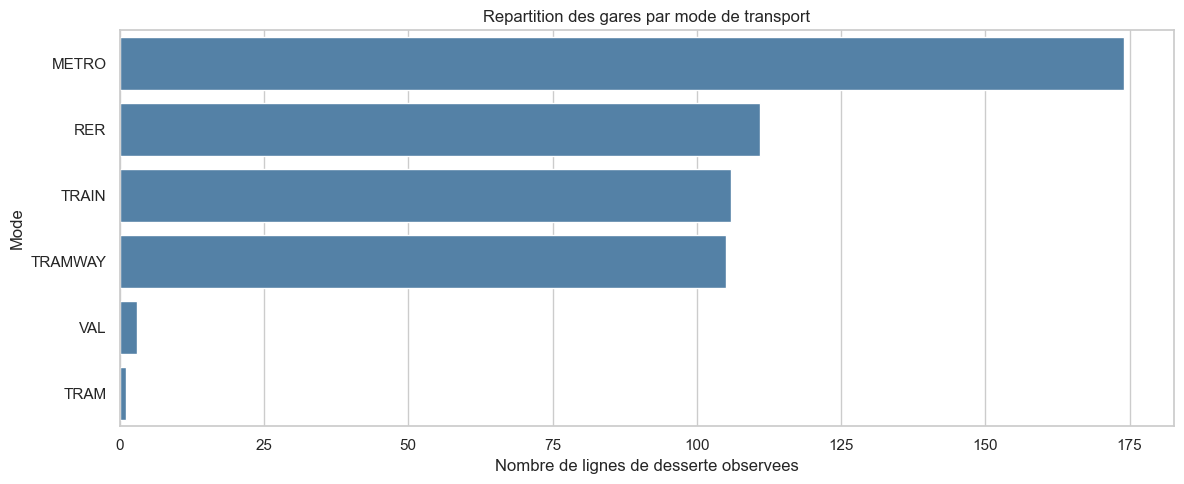

In [4]:
if 'mode' in df_gares.columns:
    mode_counts = df_gares['mode'].astype(str).value_counts(dropna=False).reset_index()
    mode_counts.columns = ['mode', 'count']
    display(mode_counts)

    sns.barplot(data=mode_counts, x='count', y='mode', color='steelblue')
    plt.title('Repartition des gares par mode de transport')
    plt.xlabel('Nombre de lignes de desserte observees')
    plt.ylabel('Mode')
    plt.tight_layout()
    plt.show()

,exploitant,count
0,RATP,279
1,SNCF,199
2,KEOLIS,11
3,RD Bièvre,4
4,RATP Dev,3
5,TRANSKEO,3
6,STRETTO,1


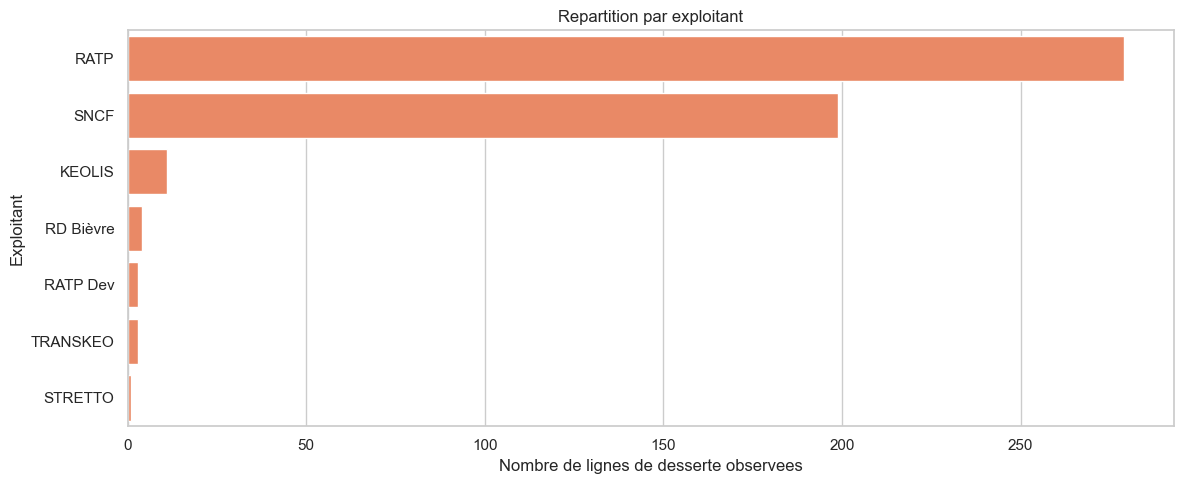

In [5]:
if 'exploitant' in df_gares.columns:
    exploitant_counts = df_gares['exploitant'].astype(str).value_counts(dropna=False).reset_index()
    exploitant_counts.columns = ['exploitant', 'count']
    display(exploitant_counts)

    sns.barplot(data=exploitant_counts, x='count', y='exploitant', color='coral')
    plt.title('Repartition par exploitant')
    plt.xlabel('Nombre de lignes de desserte observees')
    plt.ylabel('Exploitant')
    plt.tight_layout()
    plt.show()

,res_com,count
0,RER C,36
1,RER A,25
2,RER D,22
3,TRAIN H,21
4,RER B,18
5,METRO 7,18
6,TRAIN L,17
7,METRO 13,17
8,METRO 8,17
9,METRO 9,15


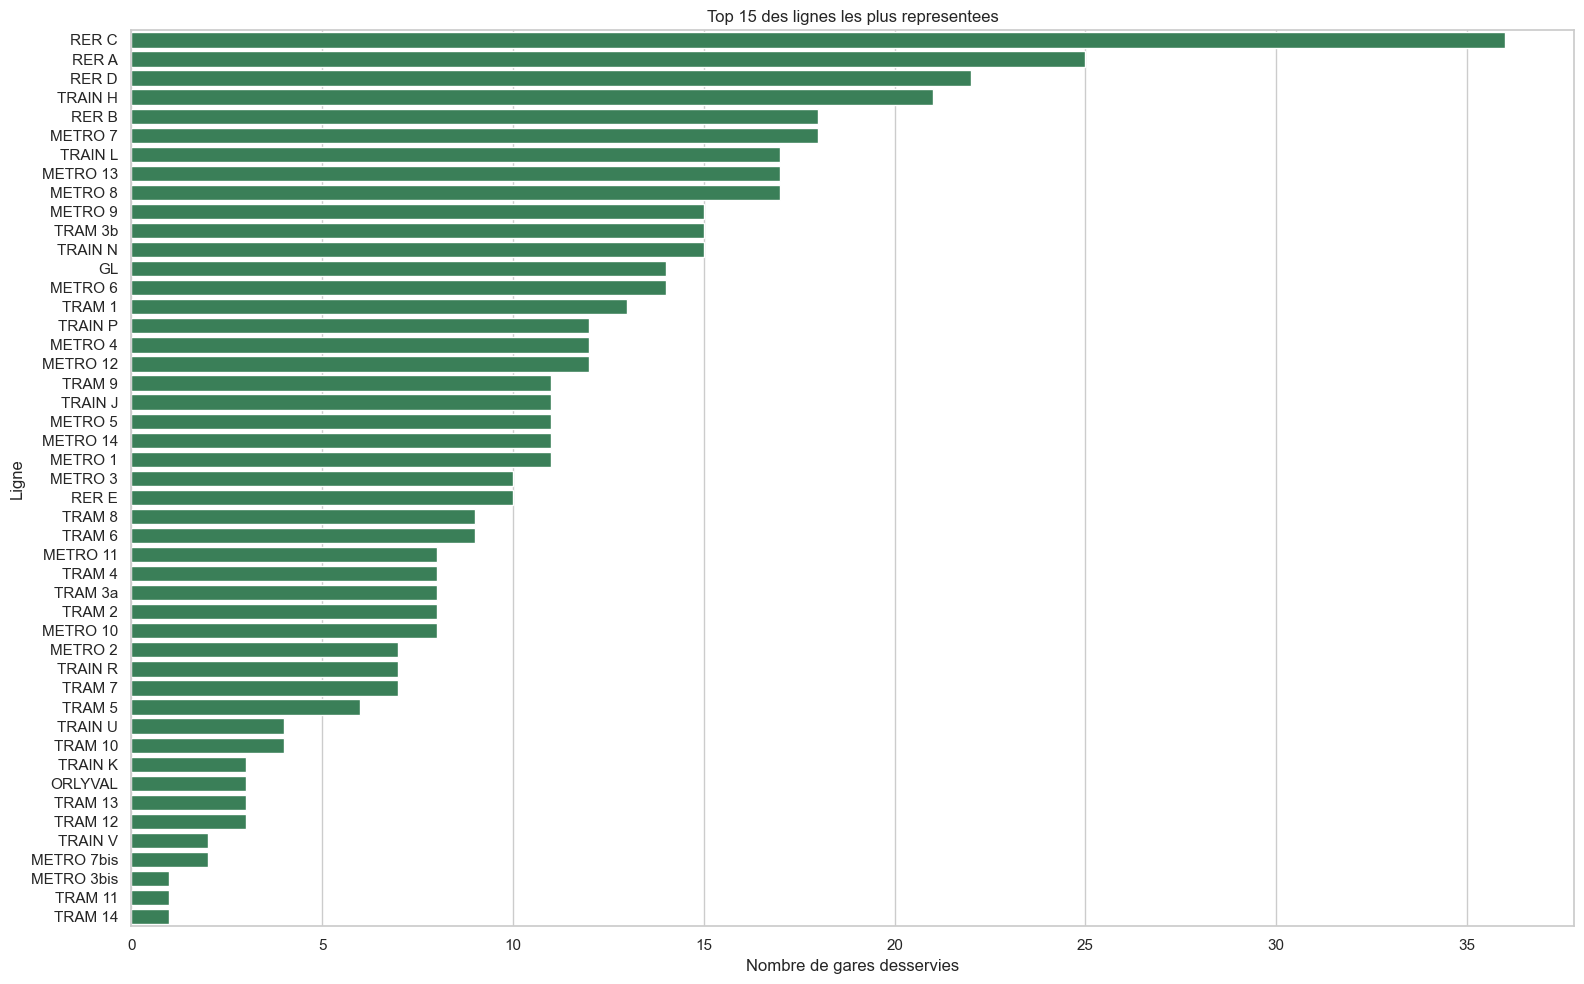

In [33]:
if 'res_com' in df_gares.columns:
    ligne_counts = df_gares['res_com'].astype(str).value_counts(dropna=False).reset_index()
    ligne_counts.columns = ['res_com', 'count']
    display(ligne_counts.head(15))

    plt.figure(figsize=(16, 10))
    sns.barplot(data=ligne_counts, x='count', y='res_com', color='seagreen')
    plt.title('Top 15 des lignes les plus representees')
    plt.xlabel('Nombre de gares desservies')
    plt.ylabel('Ligne')
    plt.tight_layout()
    plt.show()


Nombre de gares physiques uniques : 498


,nom_gares,nb_lignes
0,Charles De Gaulle-Étoile,4
1,Madeleine,3
2,Châtelet,3
3,Nation,3
4,Viroflay Rive Gauche,3
5,Saint-Lazare,3
6,Oberkampf,2
7,Barbès-Rochechouart,2
8,Gare de Lyon,2
9,Bastille,2


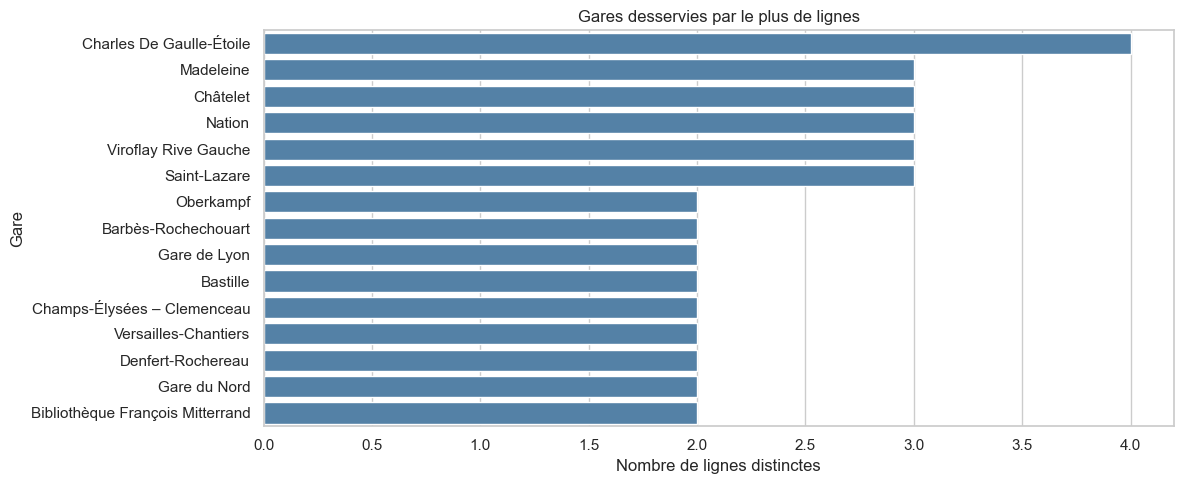

Doublons exacts sur le couple gare-ligne : 0
Conclusion Gares IDF:
- Il faut distinguer la gare physique et la desserte par ligne.
- La source est tres utile pour mesurer la multimodalite et l intensite de desserte.
- Pour un indicateur spatial, il faudra souvent dedoublonner au niveau gare puis compter les lignes, modes ou exploitants.


In [ ]:
if 'id_gares' in df_gares.columns:
    print('Nombre de gares physiques uniques :', df_gares['id_gares'].nunique(dropna=True))

if 'nom_gares' in df_gares.columns and 'res_com' in df_gares.columns:
    service_counts = df_gares.groupby('nom_gares', dropna=False)['res_com'].nunique().sort_values(ascending=False).reset_index()
    service_counts.columns = ['nom_gares', 'nb_lignes']
    display(service_counts.head(15))

    sns.barplot(data=service_counts.head(15), x='nb_lignes', y='nom_gares', color='steelblue')
    plt.title('Gares desservies par le plus de lignes')
    plt.xlabel('Nombre de lignes distinctes')
    plt.ylabel('Gare')
    plt.tight_layout()
    plt.show()

if 'id_gares' in df_gares.columns and 'res_com' in df_gares.columns:
    print('Doublons exacts sur le couple gare-ligne :', int(df_gares.duplicated(subset=['id_gares', 'res_com']).sum()))

In [12]:

if 'nom_so_gar' in df_gares.columns and 'res_com' in df_gares.columns:
    all_gares_names = df_gares['nom_so_gar'].dropna().unique()
    print(f'Nombre de gares uniques par nom_so_gar: {len(all_gares_names)}')
    print('Exemples de noms de gares par nom_so_gar:')
    display(df_gares['nom_so_gar'].dropna().unique())
    
    service_counts = df_gares.groupby('nom_so_gar', dropna=False)['res_com'].nunique().sort_values(ascending=False).reset_index()
    service_counts.columns = ['nom_so_gar', 'nb_lignes']
    display(service_counts.head(15))


Nombre de gares uniques par nom_so_gar: 33
Exemples de noms de gares par nom_so_gar:


array(['Maison de Radio France', 'Palais des Congrès', 'Notre-Dame',
       'Grande Arche', 'Colonel Rol Tanguy', 'Orly',
       'Parc des Expositions de Paris', 'Parc Novéos',
       'Parc de la Villette', 'Centre Commercial l’Ilo',
       'Centre Georges Pompidou', 'Cimetière Parisien', 'Orlyfret',
       'Porte de Montmartre', 'Pont de Rungis', 'Val de Seine',
       'Rive Gauche', 'École Polytechnique', 'Grand Palais',
       'Porte de Seine', 'Tribunal de Paris', 'Parc des Princes', 'Bécon',
       'Préfecture - Hôtel du Département', 'Stade Auguste Delaune',
       'Hôpital Européen Georges Pompidou', 'Maison de la Culture',
       'Parc Silic Centre', 'Cité des Sciences et de l’Industrie',
       'Porte des Poissoniers', 'La Monnaie', 'Hôpital Henri Mondor',
       'Jacques Duclos'], dtype=object)

,nom_so_gar,nb_lignes
0,NaN,47
1,Grand Palais,2
2,Préfecture - Hôtel du Département,2
3,Palais des Congrès,2
4,Parc des Expositions de Paris,2
5,Bécon,1
6,Centre Commercial l’Ilo,1
7,Colonel Rol Tanguy,1
8,Cité des Sciences et de l’Industrie,1
9,Centre Georges Pompidou,1


In [13]:
print('Conclusion Gares IDF:')
print('- Il faut distinguer la gare physique et la desserte par ligne.')
print('- La source est tres utile pour mesurer la multimodalite et l intensite de desserte.')
print('- Pour un indicateur spatial, il faudra souvent dedoublonner au niveau gare puis compter les lignes, modes ou exploitants.')


Conclusion Gares IDF:
- Il faut distinguer la gare physique et la desserte par ligne.
- La source est tres utile pour mesurer la multimodalite et l intensite de desserte.
- Pour un indicateur spatial, il faudra souvent dedoublonner au niveau gare puis compter les lignes, modes ou exploitants.


## 5. Analyse du dataset Arrets IDF

Un arret de reference est le lieu ou le voyageur attend, monte ou descend des vehicules; c'est souvent plus fin et plus general que la gare au sens ferroviaire.
Cette source est importante pour les indicateurs de maillage fin et de proximite, notamment quand on veut aller au plus pres de l'offre de transport et pas seulement des grandes gares.


In [15]:
arrets_cfg = {
    'base_url': 'https://data.iledefrance-mobilites.fr/api/explore/v2.1/catalog/datasets',
    'dataset_id': 'arrets',
    'rows': 2000,
    'batch_size': 100,
}

df_arrets = fetch_api_data(
    arrets_cfg['base_url'],
    arrets_cfg['dataset_id'],
    rows=arrets_cfg['rows'],
    batch_size=arrets_cfg['batch_size'],
)

print('=== Arrets IDF ===')
print(f'Lignes: {len(df_arrets)} | Colonnes: {df_arrets.shape[1]}')
print('Colonnes:')
print(df_arrets.columns.tolist())
display(df_arrets.head(5))

df_arrets_hashable = df_arrets.copy()
for column in df_arrets_hashable.columns:
    df_arrets_hashable[column] = df_arrets_hashable[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True) if isinstance(value, (list, dict)) else value
    )
print(f'Doublons exacts: {int(df_arrets_hashable.duplicated().sum())}')

arrets_profile_rows = []
for column in df_arrets.columns:
    series = df_arrets[column]
    safe_series = df_arrets_hashable[column]
    arrets_profile_rows.append({
        'column': column,
        'dtype': str(series.dtype),
        'null_count': int(series.isna().sum()),
        'null_pct': round(float(series.isna().mean() * 100), 2),
        'n_unique': int(safe_series.nunique(dropna=True)),
        'sample_values': ' | '.join(safe_series.dropna().astype(str).unique()[:5]) if safe_series.notna().any() else '-',
    })

arrets_profile = pd.DataFrame(arrets_profile_rows).sort_values(['null_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True)
display(arrets_profile)

arrets_numeric_cols = df_arrets.select_dtypes(include='number').columns.tolist()
if arrets_numeric_cols:
    display(df_arrets[arrets_numeric_cols].describe().T)


=== Arrets IDF ===
Lignes: 2000 | Colonnes: 16
Colonnes:
['arrid', 'arrversion', 'arrcreated', 'arrchanged', 'arrname', 'arrtype', 'arrxepsg2154', 'arryepsg2154', 'arrtown', 'arrpostalregion', 'arraccessibility', 'arraudiblesignals', 'arrvisualsigns', 'arrfarezone', 'zdaid', 'arrgeopoint']


,arrid,arrversion,arrcreated,arrchanged,arrname,arrtype,arrxepsg2154,arryepsg2154,arrtown,arrpostalregion,arraccessibility,arraudiblesignals,arrvisualsigns,arrfarezone,zdaid,arrgeopoint
0,415586,1423493-652809,2015-04-09T22:00:00+00:00,2026-03-25T14:05:12+00:00,Montaquoy,bus,650157,6819316,Cerny,91129,true,true,true,5,415584,"{'lon': 2.325662963123945, 'lat': 48.47219262523437}"
1,8491,1208043-43400,2014-12-28T23:00:00+00:00,2026-03-25T14:05:12+00:00,Imprimerie Nationale,bus,653656,6833821,Bondoufle,91086,true,true,true,5,43400,"{'lon': 2.371437541418495, 'lat': 48.60292971499491}"
2,461993,998781-972688,2018-07-16T22:00:00+00:00,2026-03-25T14:05:12+00:00,Chemin des Chèvres,bus,658742,6828818,Mennecy,91386,true,true,true,5,461991,"{'lon': 2.4408968278199152, 'lat': 48.558271377275766}"
3,485701,1435786-1431142,2022-08-10T08:38:07+00:00,2026-03-25T14:05:12+00:00,Boulevard des Alliés,bus,653908,6810686,Maisse,91359,true,true,true,5,485702,"{'lon': 2.3773295713967952, 'lat': 48.39483361580276}"
4,485693,1435868-1430369,2022-08-10T08:37:48+00:00,2026-03-25T14:05:12+00:00,Abribus,bus,645329,6811687,Puiselet-le-Marais,91508,true,true,true,5,485692,"{'lon': 2.261313058055181, 'lat': 48.40317357566814}"


Doublons exacts: 0


,column,dtype,null_count,null_pct,n_unique,sample_values
0,arrfarezone,object,19,0.95,6,5 | 4 | Hors Zone | 1 | 3
1,arrcreated,object,8,0.40,452,2015-04-09T22:00:00+00:00 | 2014-12-28T23:00:00+00:00 | 2018-07-16T22:00:00+00:00 | 2022-08-10T08:38:07+00:00 | 2022...
2,arrid,object,0,0.00,2000,415586 | 8491 | 461993 | 485701 | 485693
3,arrversion,object,0,0.00,2000,1423493-652809 | 1208043-43400 | 998781-972688 | 1435786-1431142 | 1435868-1430369
4,arrgeopoint,object,0,0.00,2000,"{""lat"": 48.47219262523437, ""lon"": 2.325662963123945} | {""lat"": 48.60292971499491, ""lon"": 2.371437541418495} | {""lat""..."
5,arryepsg2154,int64,0,0.00,1961,6819316 | 6833821 | 6828818 | 6810686 | 6811687
6,arrxepsg2154,int64,0,0.00,1955,650157 | 653656 | 658742 | 653908 | 645329
7,zdaid,object,0,0.00,1798,415584 | 43400 | 461991 | 485702 | 485692
8,arrname,object,0,0.00,1599,Montaquoy | Imprimerie Nationale | Chemin des Chèvres | Boulevard des Alliés | Abribus
9,arrchanged,object,0,0.00,672,2026-03-25T14:05:12+00:00 | 2026-03-25T13:37:42+00:00 | 2026-03-25T13:37:38+00:00 | 2026-03-25T07:41:17+00:00 | 2026...


,count,mean,std,min,25%,50%,75%,max
arrxepsg2154,2000.0,6.558557e+05,15434.763620,599768.0,645368.00,654097.5,664328.50,741237.0
arryepsg2154,2000.0,6.860579e+06,19539.712649,6792993.0,6852150.75,6864640.0,6873217.75,6907311.0


### Dictionnaire de donnees ARRETS BUS IDF

#### **Identifiants et versions**
- `arrid` : Identifiant unique de l’arrêt.
- `arrversion` : Version ou plage d’identifiants liés (ex: pour les arrêts fusionnés).

#### **Métadonnées temporelles**
- `arrcreated` : Date de création de l’arrêt (format ISO 8601).
- `arrchanged` : Date de dernière modification de l’arrêt.

#### **Informations de base**
- `arrname` : Nom de l’arrêt.
- `arrtype` : Type d’arrêt (ex: `bus`, `tram`, `metro`).
- `arrtown` : Commune rattachée à l’arrêt.
- `arrpostalregion` : Code postal de la commune.

#### **Géolocalisation**
- `arrxepsg2154` : Coordonnée X en EPSG:2154 (Lambert-93).
- `arryepsg2154` : Coordonnée Y en EPSG:2154 (Lambert-93).
- `arrgeopoint` : Point géographique en WGS84 (`{'lon': ..., 'lat': ...}`).

#### **Accessibilité**
- `arraccessibility` : Accessibilité PMR (`true`/`false`).
- `arraudiblesignals` : Présence de signaux sonores (`true`/`false`).
- `arrvisualsigns` : Présence de signaux visuels (`true`/`false`).

#### **Zone tarifaire et regroupement**
- `arrfarezone` : Zone tarifaire (ex: `5`).
- `zdaid` : Identifiant de la Zone de Desserte Associée (ZDA).

,arrtown,count
0,Sucy-en-Brie,30
1,Chelles,29
2,Versailles,22
3,Conflans-Sainte-Honorine,22
4,Cergy,19
5,Les Mureaux,19
6,Rambouillet,19
7,Evry-Courcouronnes,18
8,Saint-Ouen-l'Aumône,18
9,Corbeil-Essonnes,18


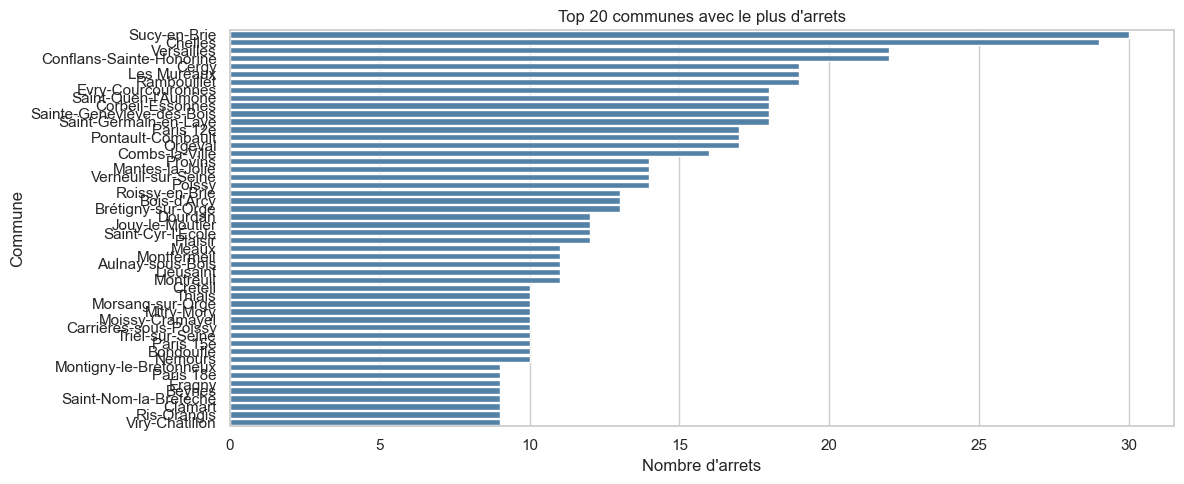

Chevauchement nominal arrets / gares : 49 noms en commun (indicatif)
Une vraie jointure doit privilegier les coordonnees ou des identifiants normalises
Conclusion Arrets IDF:
- Ce jeu est tres utile pour le maillage fin et la proximite locale.
- Il peut etre plus pertinent que les gares pour mesurer la couverture de transport du quotidien.
- Les jointures texte seules restent fragiles; une approche spatiale sera souvent preferable.


In [67]:
if 'arrtown' in df_arrets.columns:
    town_counts = df_arrets['arrtown'].astype(str).value_counts(dropna=False).head(50).reset_index()
    town_counts.columns = ['arrtown', 'count']
    display(town_counts)

    sns.barplot(data=town_counts, x='count', y='arrtown', color='steelblue')
    plt.title("Top 20 communes avec le plus d'arrets")
    plt.xlabel("Nombre d'arrets")
    plt.ylabel('Commune')
    plt.tight_layout()
    plt.show()

if 'arrname' in df_arrets.columns and 'nom_gares' in df_gares.columns:
    common = set(df_arrets['arrname'].dropna().astype(str).str.strip().str.lower().unique()) & set(df_gares['nom_gares'].dropna().astype(str).str.strip().str.lower().unique())
    print(f'Chevauchement nominal arrets / gares : {len(common)} noms en commun (indicatif)')
    print('Une vraie jointure doit privilegier les coordonnees ou des identifiants normalises')

print('Conclusion Arrets IDF:')
print('- Ce jeu est tres utile pour le maillage fin et la proximite locale.')
print('- Il peut etre plus pertinent que les gares pour mesurer la couverture de transport du quotidien.')
print('- Les jointures texte seules restent fragiles; une approche spatiale sera souvent preferable.')


### FILTRER PAR PARIS UNIQUEMENT

In [21]:
#count the number of arrets total
print('Nombre total d arrets:', len(df_arrets))
paris_mask = df_arrets['arrtown'].astype(str).str.contains('Paris', case=False, na=False)
if paris_mask.any():
    arrets_paris = df_arrets.loc[paris_mask].copy()
    print(f'Filtrage Paris applique: {len(arrets_paris)} lignes conservees')
else:
    print('Aucun filtrage Paris explicite n a pu etre applique')

Nombre total d arrets: 2000
Filtrage Paris applique: 169 lignes conservees


Statistiques descriptives sur les variables dynamiques


,arraccessibility,arraudiblesignals,arrvisualsigns
count,169,169,169
unique,4,4,4
top,true,unknown,unknown
freq,100,158,158


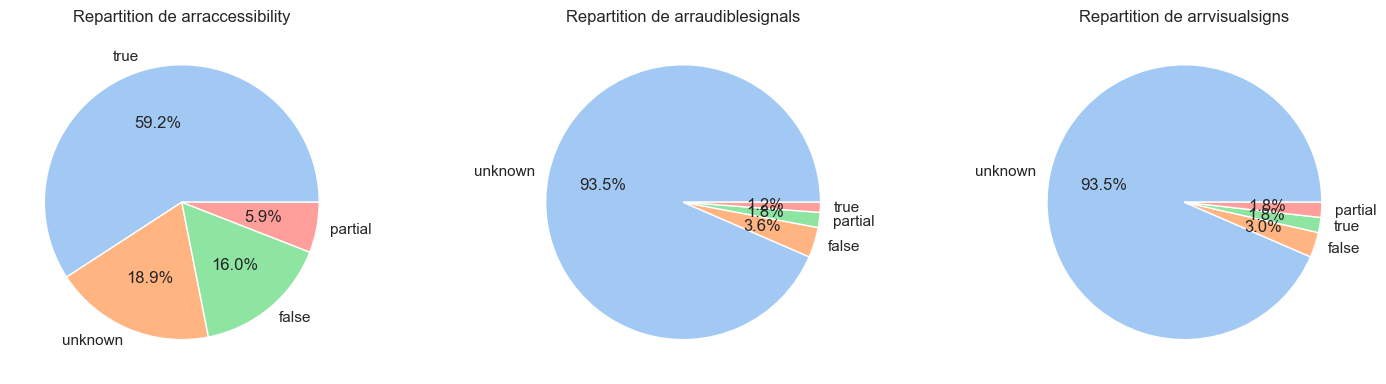

In [25]:
dynamic_cols = [column for column in ['arraccessibility', 'arraudiblesignals', 'arrvisualsigns'] if column in arrets_paris.columns]

if dynamic_cols:
    print('Statistiques descriptives sur les variables dynamiques')
    display(arrets_paris[dynamic_cols].describe())

    fig, axes = plt.subplots(1, len(dynamic_cols), figsize=(5 * len(dynamic_cols), 4))
    if len(dynamic_cols) == 1:
        axes = [axes]
    for ax, column in zip(axes, dynamic_cols):
        #create the pie chart
        counts = arrets_paris[column].astype(str).value_counts(dropna=False).reset_index()
        counts.columns = [column, 'count']
        ax.pie(counts['count'], labels=counts[column], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
        ax.set_title(f'Repartition de {column}')
    plt.tight_layout()
    plt.show()

if 'is_renting' in arrets_paris.columns:
    renting_counts = arrets_paris['is_renting'].astype(str).value_counts(dropna=False).reset_index()
    renting_counts.columns = ['is_renting', 'count']
    display(renting_counts)

if 'is_returning' in arrets_paris.columns:
    returning_counts = arrets_paris['is_returning'].astype(str).value_counts(dropna=False).reset_index()
    returning_counts.columns = ['is_returning', 'count']
    display(returning_counts)
    

,arrtype,count
0,bus,97
1,metro,5


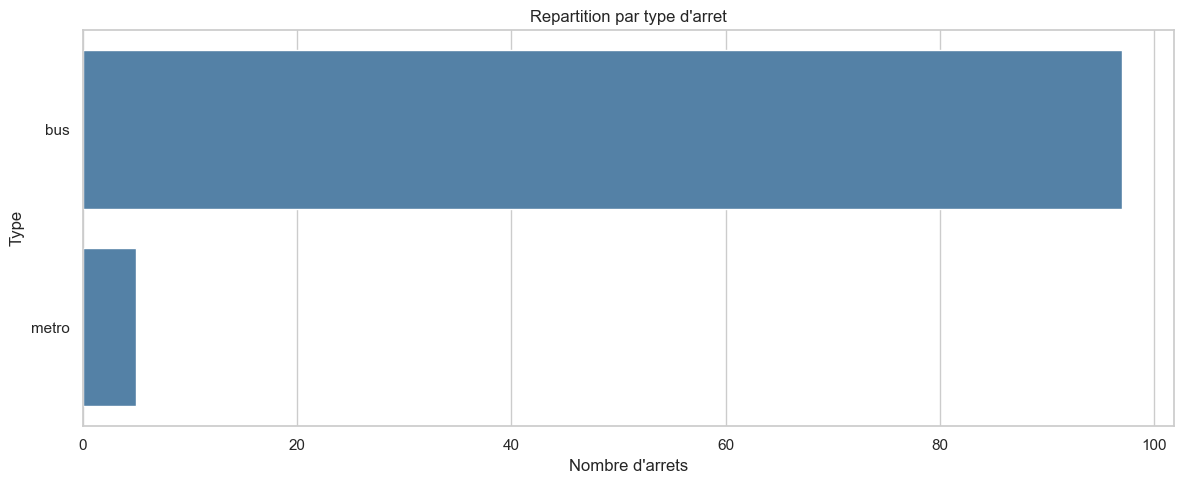

In [68]:
if 'arrtype' in arrets_paris.columns:
    type_counts = arrets_paris['arrtype'].astype(str).value_counts(dropna=False).reset_index()
    type_counts.columns = ['arrtype', 'count']
    display(type_counts)

    sns.barplot(data=type_counts, x='count', y='arrtype', color='steelblue')
    plt.title("Repartition par type d'arret")
    plt.xlabel("Nombre d'arrets")
    plt.ylabel('Type')
    plt.tight_layout()
    plt.show()

,arrfarezone,count
0,1,92
1,2,5
2,4,3
3,5,2


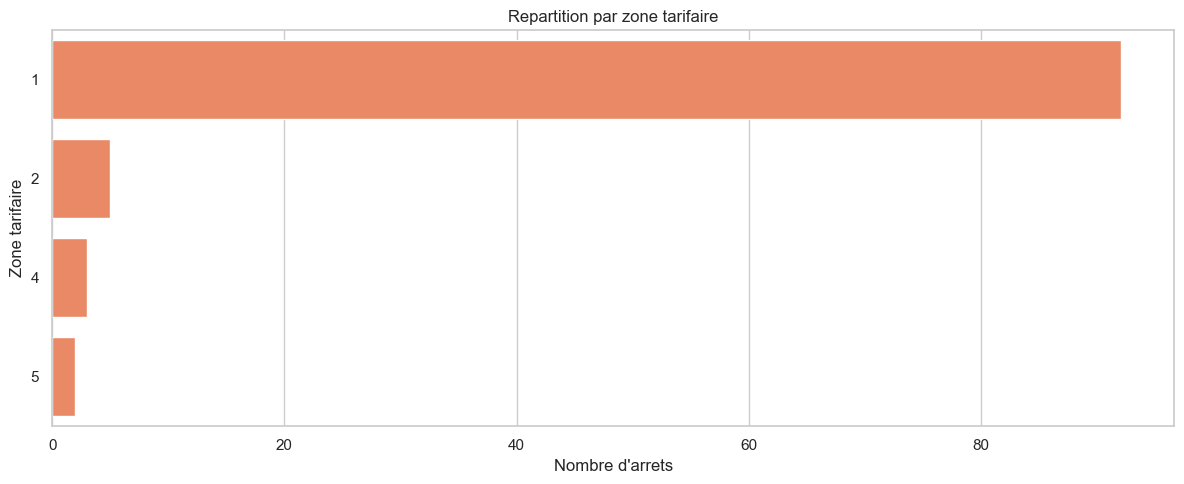

In [ ]:
if 'arrfarezone' in arrets_paris.columns:
    zone_counts = arrets_paris['arrfarezone'].astype(str).value_counts(dropna=False).reset_index()
    zone_counts.columns = ['arrfarezone', 'count']
    display(zone_counts)

    sns.barplot(data=zone_counts, x='count', y='arrfarezone', color='coral')
    plt.title('Repartition par zone tarifaire')
    plt.xlabel("Nombre d'arrets")
    plt.ylabel('Zone tarifaire')
    plt.tight_layout()
    plt.show()


,arraccessibility,count
0,true,80
1,false,16
2,partial,5
3,unknown,1


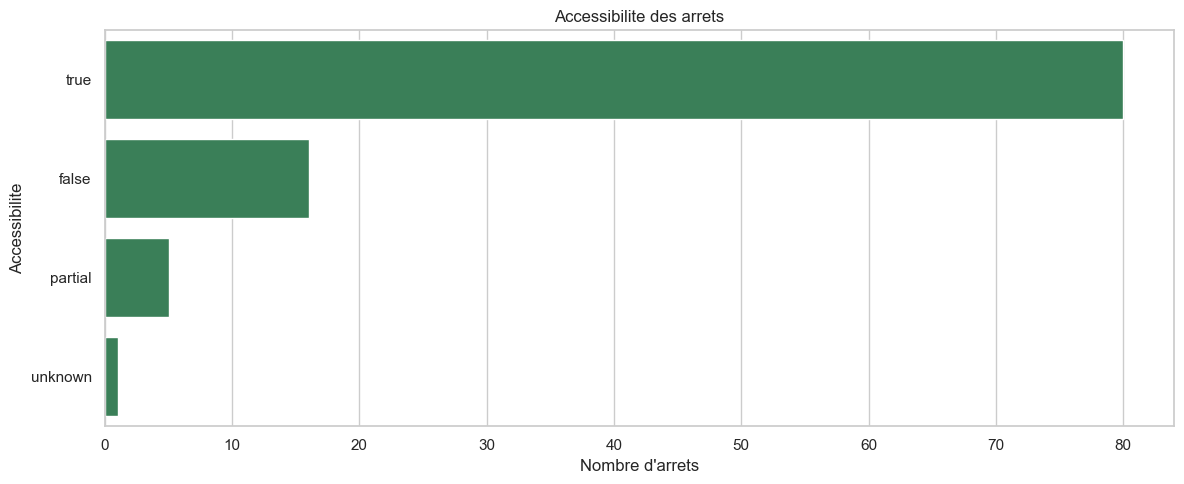

In [ ]:
if 'arraccessibility' in arrets_paris.columns:
    access_counts = arrets_paris['arraccessibility'].astype(str).value_counts(dropna=False).reset_index()
    access_counts.columns = ['arraccessibility', 'count']
    display(access_counts)

    sns.barplot(data=access_counts, x='count', y='arraccessibility', color='seagreen')
    plt.title("Accessibilite des arrets")
    plt.xlabel("Nombre d'arrets")
    plt.ylabel('Accessibilite')
    plt.tight_layout()
    plt.show()


## 6. Synthese des variables utiles et recommandations

Cette section rassemble les variables a conserver, celles a traiter avec prudence et les pistes d'indicateurs cartographiques possibles.
L'objectif n'est pas de figer des indices tout de suite, mais de preparer une couche de travail stable pour la phase suivante.


In [25]:
summary_rows = [
    {
        'Dataset': 'Velib',
        'Granularite': 'station + etat temps reel',
        'Geometrie': 'point station / coordonnees si presentes',
        'Variables cles': 'capacite, disponibilite, bornes, commune, arrondissement, paiement',
        'Limites': 'temps reel, couverture parfois au-dela de Paris',
        'Idees d indicateurs': 'densite de stations, capacite cumulee, accessibilite Velib, part de stations avec paiement',
    },
    {
        'Dataset': 'Comptage multimodal',
        'Granularite': 'site / point de comptage horaire',
        'Geometrie': 'point localise ou trajectoire locale',
        'Variables cles': 'mode, volume, type de voie, sens, trajectoire',
        'Limites': 'lecture partielle de l axe si seule une localisation ponctuelle existe',
        'Idees d indicateurs': 'intensite de trafic, mix modal, pression par mode, comparaison sens / trajectoires',
    },
    {
        'Dataset': 'Gares IDF',
        'Granularite': 'gare physique + desserte par ligne',
        'Geometrie': 'point gare / station',
        'Variables cles': 'gare, ligne, mode, exploitant',
        'Limites': 'doublons logiques par ligne',
        'Idees d indicateurs': 'accessibilite ferree, intensite de desserte, multimodalite',
    },
    {
        'Dataset': 'Arrets IDF',
        'Granularite': 'arret de reference fin',
        'Geometrie': 'point d arret',
        'Variables cles': 'identifiant, libelle, type, zone, commune',
        'Limites': 'jointure textuelle seule insuffisante',
        'Idees d indicateurs': 'maillage fin, proximite transport, couverture locale, comparaison avec les gares',
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print('Recommandations de travail:')
print('1. Conserver les identifiants, noms, categories, geometries et variables de desserte.')
print('2. Isoler les colonnes purement dynamiques avant de calculer des indices structurels.')
print('3. Prioriser les jointures spatiales ou par identifiant avant les jointures texte.')
print('4. Utiliser Velib pour Paris, Gares pour la desserte ferree et Arrets pour le maillage fin.')
print('5. Garder le comptage multimodal comme source de pression de trafic local, pas comme couche complete d occupation territoriale.')


,Dataset,Granularite,Geometrie,Variables cles,Limites,Idees d indicateurs
0,Velib,station + etat temps reel,point station / coordonnees si presentes,"capacite, disponibilite, bornes, commune, arrondissement, paiement","temps reel, couverture parfois au-dela de Paris","densite de stations, capacite cumulee, accessibilite Velib, part de stations avec paiement"
1,Comptage multimodal,site / point de comptage horaire,point localise ou trajectoire locale,"mode, volume, type de voie, sens, trajectoire",lecture partielle de l axe si seule une localisation ponctuelle existe,"intensite de trafic, mix modal, pression par mode, comparaison sens / trajectoires"
2,Gares IDF,gare physique + desserte par ligne,point gare / station,"gare, ligne, mode, exploitant",doublons logiques par ligne,"accessibilite ferree, intensite de desserte, multimodalite"
3,Arrets IDF,arret de reference fin,point d arret,"identifiant, libelle, type, zone, commune",jointure textuelle seule insuffisante,"maillage fin, proximite transport, couverture locale, comparaison avec les gares"


Recommandations de travail:
1. Conserver les identifiants, noms, categories, geometries et variables de desserte.
2. Isoler les colonnes purement dynamiques avant de calculer des indices structurels.
3. Prioriser les jointures spatiales ou par identifiant avant les jointures texte.
4. Utiliser Velib pour Paris, Gares pour la desserte ferree et Arrets pour le maillage fin.
5. Garder le comptage multimodal comme source de pression de trafic local, pas comme couche complete d occupation territoriale.
